In [1]:
from typing import List,TypedDict,Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

e:\Machine Learning and Data Science\Advanced-RAGS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
docs = (
    PyPDFLoader("documents/Company_Policies.pdf").load()
    + PyPDFLoader("documents/Company_Profile.pdf").load()
    + PyPDFLoader("documents/Product_and_Pricing.pdf").load()
)

### Chunking

In [3]:
chunks = RecursiveCharacterTextSplitter(chunk_size=200,chunk_overlap=50).split_documents(docs)

In [4]:
len(chunks)

46

### Embeddings and Retriever

In [5]:
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
vector_stores = FAISS.from_documents(chunks,embeddings)

In [6]:
retriever = vector_stores.as_retriever(search_type = 'similarity',search_kwargs={"k":1})

In [7]:
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

## State

In [8]:
class State(TypedDict):

    question: str

    current_query: str
    docs: List[Document]
    sub_answer : List[str]
    context: str
    answer: str
    route: Literal["no_retriever", "single_retrieval", "multi_retrieval"]

    steps: int
    max_steps: int

### Route Decision

In [9]:
class RouteDecision(BaseModel):
    route: Literal["no_retriever", "single_retrieval", "multi_retrieval"] = Field(
        ...,
        description="Routing strategy for answering the question."
    )

route_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a routing decision system.\n"
            "Return JSON that matches this schema:\n"
            "{{'route': 'no_retriever' | 'single_retrieval' | 'multi_retrieval'}}\n\n"
            "Guidelines:\n"
            "- no_retriever → for general knowledge, definitions, simple explanations.\n"
            "- single_retrieval → for factual queries needing one lookup.\n"
            "- multi_retrieval → for complex, multi-hop, comparison, or reasoning questions.\n"
            "- If unsure, choose single_retrieval."
        ),
        (
            "human", "Question: {question}"
        ),
    ]
)

route_llm = route_prompt | llm.with_structured_output(RouteDecision)


def decide_route(state: State):
    out = route_llm.invoke({"question":state['question']})

    return {"route":out.route}

In [10]:
def generate(state: State):
    out = llm.invoke(state['question'])

    return {'answer': out.content}

In [11]:
def retrieval(state: State):
    
    docs = retriever.invoke(state['question'])

    return {'docs':docs}



In [12]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG Assistant\n"
            "Answer the user question using only the provided context"
        ),
        (
            "human",
            "Question:\n{question}\n"
            "Context:\n{context}"
        ),
    ]
)

def single_step_generate(state: State):

    context = " ".join(d.page_content for d in state['docs'])

    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question = state['question'],
            context = context
        )
    )

    return {'answer':out.content,"context":context}


## Multi HOP Version

### Multi retriever step

In [13]:
def multi_retrieval(state: State):
    """
    Uses current_query (NOT original question after step 1).
    Appends newly retrieved docs to accumulated docs list.
    """

    query = state.get('current_query') or state['question']

    new_docs = retriever.invoke(query)

    new_text = " ".join(d.page_content for d in new_docs)
    context = state.get("context","") + " " + new_text

    return {'docs': state.get("docs", [])+new_docs,'context':context}

### Generation Step

In [14]:
class StepOutput(BaseModel):
    sub_answer: str
    next_query: str
    is_completed: bool

step_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are answering a multi-hop question step by step.
Given the original question, what you've found so far, and the retrieved docs,
produce a partial answer and a refined query for the next retrieval step.
If you have enough information to fully answer the question, set is_complete=true."""),
        ("human", """Original question: {question}
Previous sub-answers: {sub_answers}
Retrieved Context: {context}
Current step: {steps}""")
    ])

step_chain = step_prompt | llm.with_structured_output(StepOutput)

def generate_step(state: State):
    result = step_chain.invoke({
        "question": state['question'],
        "sub_answers": state.get("sub_answer",[]),
        "context": state['context'],
        "steps" : state['steps']
    })

    return {
        "sub_answer": state.get("sub_answer",[]) + [result.sub_answer],
        "current_query": result.next_query,
        "steps": state["steps"] + 1,
        # Store is_complete signal in state so the edge can read it
        "is_complete": result.is_completed,
    }

### final generation

In [15]:
final_prompt = ChatPromptTemplate.from_messages([
        ("system", "Synthesize a final answer from all collected evidence."),
        ("human", """Original question: {question}
All retrieved context: {context}
Step-by-step sub-answers: {sub_answers}""")
    ])

final_chain = final_prompt | llm

def final_generate(state: State):
    """Runs ONCE after the loop exits."""
    response = final_chain.invoke({
        "question": state["question"],
        "context": state["context"],
        "sub_answers": state["sub_answer"],
    })
    return {"answer": response.content}

In [16]:
def should_continue(state: State) -> str:
    """
    This function IS the loop controller.
    Returns "loop" → goes back to retrieve()
    Returns "end"  → exits to final_generate()
    
    Two exit conditions:
    1. LLM signalled is_complete = True
    2. Hard cap: steps >= max_steps (prevents infinite loops)
    """
    if state.get("is_complete") or state["steps"] >= state["max_steps"]:
        return "end"
    return "loop"

### Routing 

In [17]:
def route_after_decision(state: State):
    if state['route'] == "no_retriever":
        return "no_retriever"
    if state['route'] == "multi_retrieval":
        return "multi_retrieval"
    
    return "single_retrieval"

## State

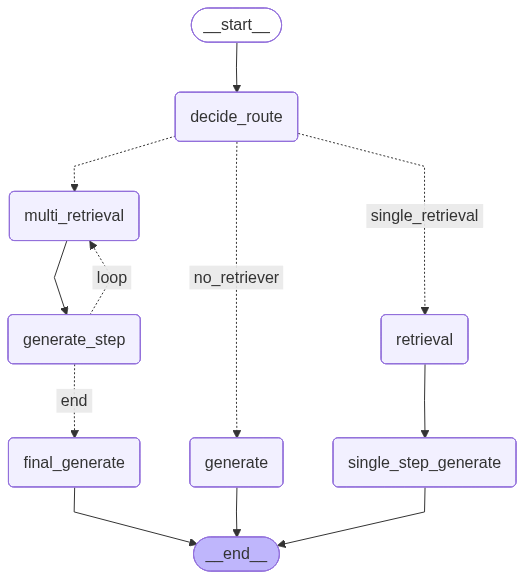

In [18]:
graph = StateGraph(State)

graph.add_node("decide_route",decide_route)
graph.add_node("generate",generate)
graph.add_node("retrieval",retrieval)
graph.add_node("single_step_generate",single_step_generate)
graph.add_node("multi_retrieval",multi_retrieval)
graph.add_node("generate_step",generate_step)
graph.add_node("final_generate", final_generate)


graph.add_edge(START,"decide_route")
graph.add_conditional_edges(
    "decide_route",
    route_after_decision,
    {"no_retriever":"generate","multi_retrieval":"multi_retrieval","single_retrieval":"retrieval"}
)

graph.add_edge("generate",END)

graph.add_edge("retrieval","single_step_generate")
graph.add_edge("single_step_generate",END)

graph.add_edge("multi_retrieval","generate_step")


graph.add_conditional_edges(
    "generate_step",
    should_continue,
    {
        "loop": "multi_retrieval",
        "end": "final_generate"
    }
)

graph.add_edge("final_generate",END)

app = graph.compile()
app


In [ ]:
result = app.invoke({'question':"Give me details about company hr policy,leave policy,workspace conduct?","steps": 0,"max_steps": 3}) 

In [ ]:
print(result['answer'])

The company has a strict anti-harassment policy. Regarding the leave policy, employees are encouraged to maintain a healthy work-life balance, with 18 working days of annual leave and 10 working days of sick leave provided per year. In terms of workplace conduct, employees are expected to act professionally and ethically at all times, maintain confidentiality of company and client information, and avoid conflicts of interest. Any violation of company policies may result in disciplinary action.


In [ ]:
print(result['route'])

multi_retrieval
